# André Santos Rocha

# Question 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def rmvt(mu, sigma, v, size):
    """
    Generate random variates from a multivariate Student's t-distribution.

    Parameters:
    mu (array_like): Mean vector (location parameter).
    sigma (array_like): Scale matrix (covariance-like matrix).
    v (int): Degrees of freedom.
    size (int): Number of random vectors to generate.

    Returns:
    numpy.ndarray: An array of generated random vectors.
    """
    d = len(mu)

    # generate multivariate normal samples with mean mu and scatter matrix sigma
    Z = np.random.multivariate_normal(np.zeros(d), sigma, size)

    # generate chi-squared samples with v degrees of freedom
    W = np.random.chisquare(v, size)

    # Combine to form multivariate t-distribution samples
    # x = mu + (Z * sqrt(v / W))
    samples = mu + Z * np.sqrt(v / W)[:, np.newaxis] # Corrected: Removed incorrect function call
    return samples

In [3]:
#generate datasets
MVS1 = rmvt(np.zeros(2), np.asarray([ [1, 1], [1, 4]]), 5, 100)
MVS2 = rmvt(np.asarray([2,2]), np.asarray([ [1, 1], [1, 4]]), 3, 100)
MVS3 = rmvt(np.asarray([2,2]), np.asarray([ [4, 4], [4, 16]]), 1, 100)

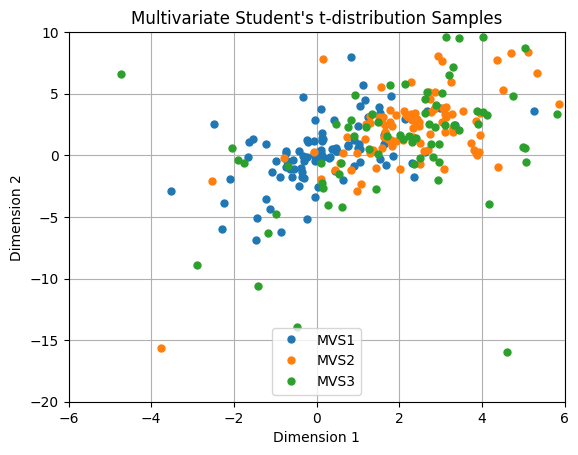

In [4]:
# plot data
fig, ax = plt.subplots()
plt.plot(MVS1[:,0],MVS1[:,1], '.', label='MVS1', markersize=10)
plt.plot(MVS2[:,0],MVS2[:,1], '.', label='MVS2', markersize=10)
plt.plot(MVS3[:,0],MVS3[:,1], '.', label='MVS3', markersize=10)
plt.title('Multivariate Student\'s t-distribution Samples')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.xlim(-6,6)
plt.ylim(-20,10)
plt.legend()
plt.grid(True)
plt.show()

# Question 2

In [5]:
#Generate new samples
X_samples = rmvt(np.zeros(3), np.asarray([ [1, 1, 1], [1, 4, 4], [1, 4, 9]]), 5, 1000)

In [6]:
#Projection matrix
proj_mat = np.asarray([[1,1,1,1,1], [1,-1,1,-1,0], [0,-1,-1,0,2]]).T

#Normalization by column
column_norms = np.linalg.norm(proj_mat, axis=0, keepdims=True) # Calculate l2 norm per column
proj_mat_norm = proj_mat / column_norms # Divide each column by its norm

shift_factor = np.asarray([1,2,3,4,5])

X_new = X_samples @ proj_mat_norm.T + shift_factor[np.newaxis,:]

# Corrected function name and covariance matrix definition
noise = np.random.multivariate_normal(np.zeros(5), np.diag(0.025 * np.ones(5)), size=1000)

X = X_new + noise

# Question 3

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_pca = pca.fit_transform(X, ) # fit

print(f"Explained variances:\n {pca.explained_variance_}")
print(f"Explained singular values:\n {pca.singular_values_}")
print(f"Explained full principal components\n {pca.components_}")



Explained variances:
 [18.70630556  3.11304524  1.18099136  0.02898809  0.02652424]
Explained singular values:
 [136.70259417  55.76676602  34.34836775   5.3813663    5.14759276]
Explained full principal components
 [[ 0.30642516 -0.53524078 -0.04511274 -0.18301319  0.76425908]
 [ 0.54092899 -0.0516892   0.75250017 -0.25607727 -0.26998514]
 [ 0.24646906  0.5733133   0.22754389  0.59104654  0.45765995]
 [ 0.48298934 -0.42283629 -0.30039634  0.60515703 -0.36259864]
 [ 0.56522008  0.45096215 -0.53823243 -0.43055727 -0.04566922]]


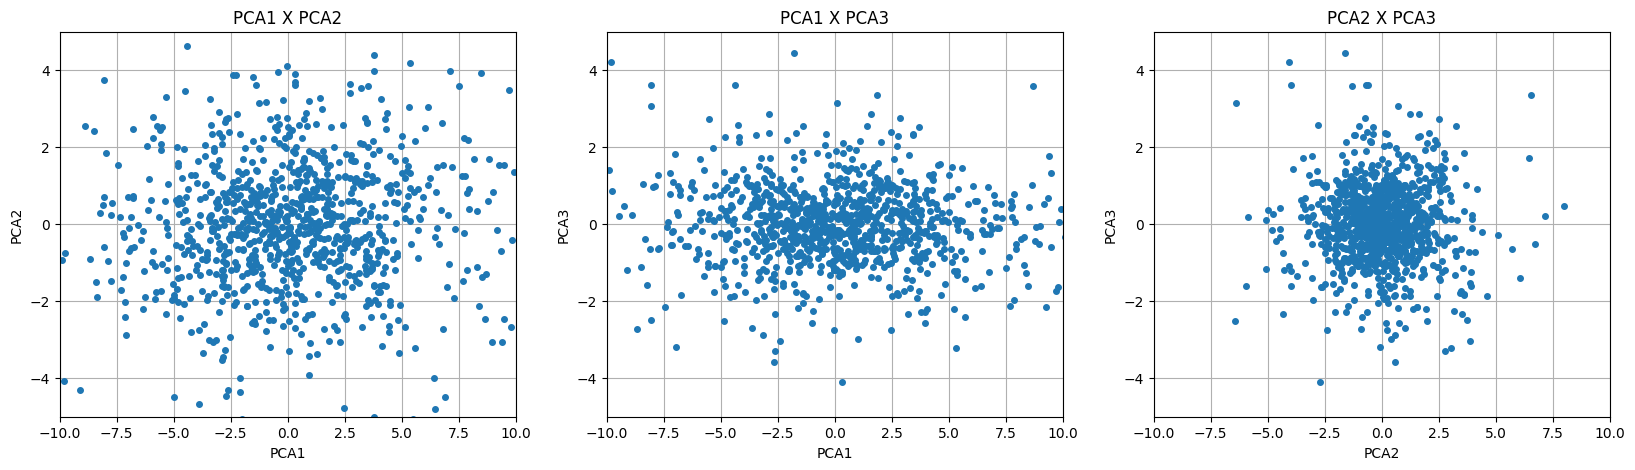

In [8]:
#plot pairs of fist three principal components
fig, ax = plt.subplots(1, 3, figsize=(20, 5)) # Increased figure size (width=15, height=5)

col = 0
for i, j in zip((1,1,2),(2,3,3)):
  ax[col].plot(X_pca[:,i-1], X_pca[:,j-1], ".", markersize=8)
  ax[col].set_title(f"PCA{i} X PCA{j}")
  ax[col].set_xlabel(f"PCA{i}")
  ax[col].set_ylabel(f"PCA{j}")
  ax[col].grid(True)
  ax[col].set_xlim(-10,10)
  ax[col].set_ylim(-5,5)
  col += 1

plt.show()

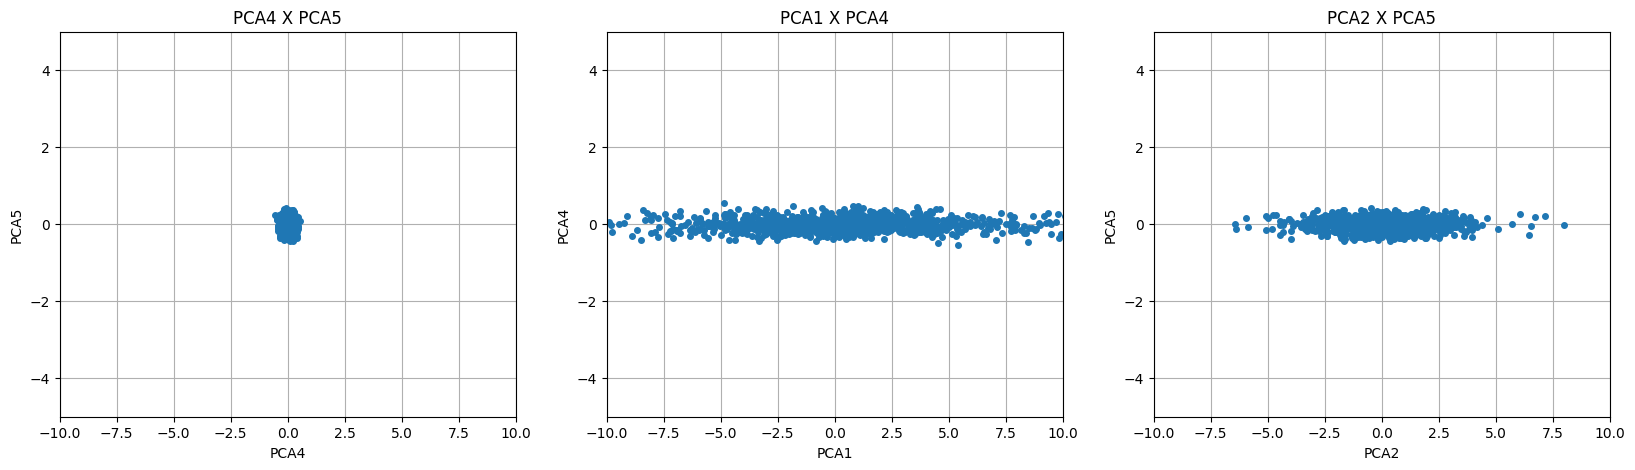

In [9]:
#plot pairs of fist three principal components
fig, ax = plt.subplots(1, 3, figsize=(20, 5)) # Increased figure size (width=15, height=5)

col = 0
for i,j in zip((4,1,2), (5,4,5)):
  ax[col].plot(X_pca[:,i-1], X_pca[:,j-1], ".", markersize=8)
  ax[col].set_title(f"PCA{i} X PCA{j}")
  ax[col].set_xlabel(f"PCA{i}")
  ax[col].set_ylabel(f"PCA{j}")
  ax[col].grid(True)
  ax[col].set_xlim(-10,10)
  ax[col].set_ylim(-5,5)
  col += 1

plt.show()

-> Comment

Looking at the plots it is notable that the variance decreases as we pass through the columns of the matrix. If we compare the most extreme cases PCA1 X PCA2 and  PCA4 X PCA5, it is clear that PCA1 and PCA2 share a much higher variance, since their plot is widely distributed. On the other hand, PCA4 X PCA5 is concentrated next to the origin, to evidenciate the poor variance.

#Question 4

In [10]:
import numpy as np
from sklearn.decomposition import PCA

k = 5

# Center EXACTLY like sklearn
Xc = X - pca.mean_

U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

# Align signs
sign = np.sign((pca.components_[:k] * Vt[:k]).sum(axis=1, keepdims=True))
pcs_svd = Vt[:k] * sign
print("components match:", np.allclose(pca.components_[:k], pcs_svd, atol=1e-6))

print(pca.components_)
print(pcs_svd)

components match: True
[[ 0.30642516 -0.53524078 -0.04511274 -0.18301319  0.76425908]
 [ 0.54092899 -0.0516892   0.75250017 -0.25607727 -0.26998514]
 [ 0.24646906  0.5733133   0.22754389  0.59104654  0.45765995]
 [ 0.48298934 -0.42283629 -0.30039634  0.60515703 -0.36259864]
 [ 0.56522008  0.45096215 -0.53823243 -0.43055727 -0.04566922]]
[[ 0.30642516 -0.53524078 -0.04511274 -0.18301319  0.76425908]
 [ 0.54092899 -0.0516892   0.75250017 -0.25607727 -0.26998514]
 [ 0.24646906  0.5733133   0.22754389  0.59104654  0.45765995]
 [ 0.48298934 -0.42283629 -0.30039634  0.60515703 -0.36259864]
 [ 0.56522008  0.45096215 -0.53823243 -0.43055727 -0.04566922]]


-> Comment

Components macth indeed. Which was expected since scikit-learn implementation of PCA is svd-based.

# Question 5

In [11]:
# generate 100 observations from standard Cauchy distribution
cauchy_dist = rmvt(np.zeros(5), np.eye(5), 1, 100)

#replace 10% of last observations
X_altered = np.concatenate((X[:-100, :], cauchy_dist), axis=0)

Text(0, 0.5, 'Second coordinate')

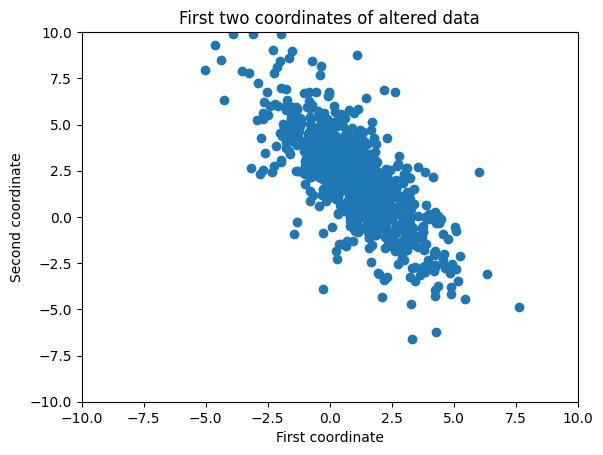

In [12]:
# plot first two coordinates of original data
plt.scatter(X[:,0], X[:,1])
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.title("First two coordinates of altered data")
plt.xlabel("First coordinate")
plt.ylabel("Second coordinate")


Text(0, 0.5, 'Second coordinate')

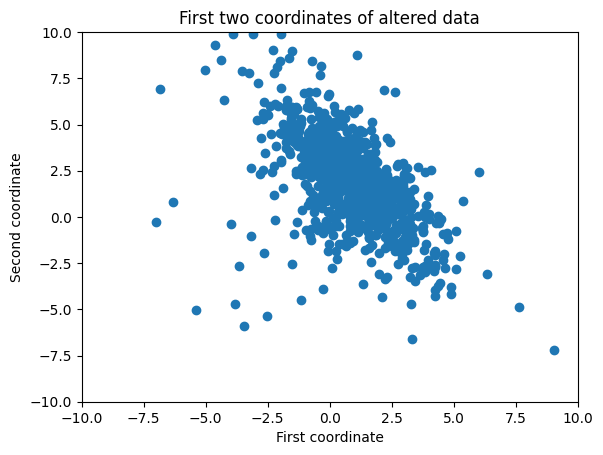

In [13]:
# plot first two coordinates
plt.scatter(X_altered[:,0], X_altered[:,1])
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.title("First two coordinates of altered data")
plt.xlabel("First coordinate")
plt.ylabel("Second coordinate")


-> Comment

The variance of the data seems to have augmented with the presence of otuliers.
This could be a problem for the PCA because the variance may dominate and cause
distorsions.

# Question 6

In [14]:
pca_altered = PCA(n_components=5)

X_pca_altered = pca_altered.fit_transform(X_altered, ) # fit

print(f"Explained variances:\n {pca_altered.explained_variance_}")
print(f"Explained singular values:\n {pca_altered.singular_values_}")
print(f"Explained full principal components\n {pca_altered.components_}")



Explained variances:
 [31.17013926 17.38888334  6.74101364  5.21930536  2.74154746]
Explained singular values:
 [176.4623731  131.80096533  82.06261407  72.20862865  52.33360217]
Explained full principal components
 [[ 0.04233869  0.44281467 -0.54652204  0.58548064 -0.40081004]
 [ 0.38360933 -0.21592739 -0.35049446  0.32789638  0.75885232]
 [-0.09454856  0.7967612   0.40758455  0.0783205   0.42892061]
 [ 0.4115419  -0.21363527  0.63706902  0.57408002 -0.22263966]
 [ 0.82021043  0.27716797 -0.08053067 -0.4625953  -0.17306983]]


In [15]:
print(f"Original Explained variances:\n {pca.explained_variance_}")
print(f"Original Explained singular values:\n {pca.singular_values_}")
print(f"Original Explained full principal components\n {pca.components_}")


Original Explained variances:
 [18.70630556  3.11304524  1.18099136  0.02898809  0.02652424]
Original Explained singular values:
 [136.70259417  55.76676602  34.34836775   5.3813663    5.14759276]
Original Explained full principal components
 [[ 0.30642516 -0.53524078 -0.04511274 -0.18301319  0.76425908]
 [ 0.54092899 -0.0516892   0.75250017 -0.25607727 -0.26998514]
 [ 0.24646906  0.5733133   0.22754389  0.59104654  0.45765995]
 [ 0.48298934 -0.42283629 -0.30039634  0.60515703 -0.36259864]
 [ 0.56522008  0.45096215 -0.53823243 -0.43055727 -0.04566922]]


-> Comment

We can see that the presence of the outliers contaminated the data and increased the variance. This way, the variance was dominated by outliers and that is why the components do not match.

In [34]:
from sklearn.covariance import MinCovDet


mcd_contaminated = MinCovDet().fit(X_altered)

mu_mcd = mcd_contaminated.location_        # robust mean (p,)
Sigma_mcd = mcd_contaminated.covariance_   # robust covariance (p,p)

print("sample mean (first 5):", X_altered.mean(axis=0)[:5])
print("MCD mean    (first 5):", mu_mcd[:5])
print("max |sample mean|:", np.abs(X_altered.mean(axis=0)).max())
print("max |MCD mean|   :", np.abs(mu_mcd).max())

sample mean (first 5): [0.85661216 1.64415267 2.84030231 3.47896735 4.43115239]
MCD mean    (first 5): [1.06547486 1.87358084 3.0143347  3.9356288  5.10079053]
max |sample mean|: 4.431152385522645
max |MCD mean|   : 5.100790534997909


-> Comment

The mean estimate is close to the sample mean and looks reasonable.

In [36]:
# run svd on the corrected MCD-estimated covariance matrix
U, S, Vt = np.linalg.svd(Sigma_mcd, full_matrices=False)

# check if components match with those from task 3 and 4
pcs_mcd = Vt[:k]                 # robust principal directions (rows)

# Align signs
sign = np.sign((pca.components_ * pcs_mcd).sum(axis=1, keepdims=True))
pcs_mcd_aligned = pcs_mcd * sign
print(f"pcs_mcd:\n {pcs_mcd}")
print(f"pca.components_:\n {pca.components_}")
print(f"pcs_svd:\n {pcs_svd}")

# Scores: PCA transform equals Xc @ components_.T
print("components match pca vs mcd:", np.allclose(pca.components_[0], pcs_mcd_aligned[0], atol=1e-2))
print("components match svd task 4 vs svd on mcd:", np.allclose(pcs_svd[0], pcs_mcd_aligned[0], atol=1e-2))

pcs_mcd:
 [[-0.32921779  0.54638045  0.01502149  0.20575728 -0.74197194]
 [-0.52872436  0.01674546 -0.76030993  0.23316633  0.29619656]
 [ 0.24870813  0.5658186   0.20592179  0.59188679  0.47461545]
 [ 0.58140003 -0.33049039 -0.3999514   0.50662464 -0.36894506]
 [ 0.46063486  0.52135728 -0.46833562 -0.54433345  0.01910391]]
pca.components_:
 [[ 0.30642516 -0.53524078 -0.04511274 -0.18301319  0.76425908]
 [ 0.54092899 -0.0516892   0.75250017 -0.25607727 -0.26998514]
 [ 0.24646906  0.5733133   0.22754389  0.59104654  0.45765995]
 [ 0.48298934 -0.42283629 -0.30039634  0.60515703 -0.36259864]
 [ 0.56522008  0.45096215 -0.53823243 -0.43055727 -0.04566922]]
pcs_svd:
 [[ 0.30642516 -0.53524078 -0.04511274 -0.18301319  0.76425908]
 [ 0.54092899 -0.0516892   0.75250017 -0.25607727 -0.26998514]
 [ 0.24646906  0.5733133   0.22754389  0.59104654  0.45765995]
 [ 0.48298934 -0.42283629 -0.30039634  0.60515703 -0.36259864]
 [ 0.56522008  0.45096215 -0.53823243 -0.43055727 -0.04566922]]
components mat

-> Comment

Even though the components do not match exactly, we can observe that MCD is a good and robust approximation to resist the outliers. That robustness delivered good approximations of the original components.